Imports:

In [10]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import random_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

In [2]:
# Function used to flatten dataset to make linear
#   for usage in the mlp
def flatten(data):
    dataSize = len(data)
    x_flat = torch.zeros(dataSize, 784)
    y_flat = torch.zeros(dataSize)
    
    c = 0
    for img, lbl in data:
        img = torch.tensor(np.copy(img).reshape(784))
        lbl = torch.tensor(lbl)
    
        x_flat[c] = img
        y_flat[c] = lbl
        c += 1
    return x_flat, y_flat

# Function used to display the confusion matrix
#   of a given model
def showConfusionMatrix(model, X, y, title):
    y_pred = model.predict(X)

    plt.figure(figsize=(16,10))
    cm = confusion_matrix(y_pred, y)
    ax = sns.heatmap(cm, annot=True, cmap='Blues')
    ax.set_title(title);
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values');
    plt.show()

EMNIST Dataset Initialization:

In [3]:
# Retrieve the EMNIST Balanced dataset and store into the data directory
train_data = datasets.EMNIST(root = 'data', split = 'balanced', train = True, transform = ToTensor(), download = True)
test_data = datasets.EMNIST(root = 'data', split = 'balanced', train = False, transform = ToTensor(), download = True)

# Retrieve the validation data from the training set
train_data, valid_data = random_split(train_data,[90240,22560])

# Retrieve the MNIST Balanced dataset and store into the data directory
train_digits = datasets.MNIST(root='data', download=True, train=True, transform=ToTensor())
test_digits = datasets.MNIST(root='data', download=True, train=False, transform=ToTensor())

# Retrieve the validation data from the training set
train_digits, valid_digits = random_split(train_digits,[50000, 10000])

Flatten EMNIST Dataset:

In [4]:
# Flatten the datasets for usage in the mlp using
#    the function defined at the begining
X_train, y_train = flatten(train_data)
X_test, y_test = flatten(test_data)
X_valid, y_valid = flatten(valid_data)

X_train_d, y_train_d = flatten(train_digits)
X_test_d, y_test_d = flatten(test_digits)
X_valid_d, y_valid_d = flatten(valid_digits)

Previous MLP with EMNIST dataset alone:

In [5]:
# Create the MLP with the optimal parameters trained previously
mlp1 = MLPClassifier(max_iter = 100, activation = 'relu', learning_rate = 'adaptive', solver = 'adam')

# Fit the dataset to the EMNIST training set
mlp1.fit(X_train, y_train)

# Calculate the training and the test accuracy
emnist_test_acc = mlp1.score(X_test, y_test)
emnist_train_acc = mlp1.score(X_train, y_train)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Previous MLP with MNIST + EMNIST datasets:

In [6]:
# Create the MLP with the optimal parameters trained previously
mlp2 = MLPClassifier(max_iter = 100, activation = 'relu', learning_rate = 'adaptive', solver = 'adam')

# Fit (train) the dataset to the MNIST training set
mlp2.fit(X_train_d, y_train_d)

# Fit (train) the dataset to the EMNIST training set
mlp2.fit(X_train, y_train)

# Calculate the training and the test accuracy
mnist_emnist_test_acc = mlp2.score(X_test, y_test)
mnist_emnist_train_acc = mlp2.score(X_train, y_train)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
print(mnist_emnist_train_acc)
print(mnist_emnist_test_acc)

0.9167664007092199
0.8075


Evaluation of EMNIST mlp:

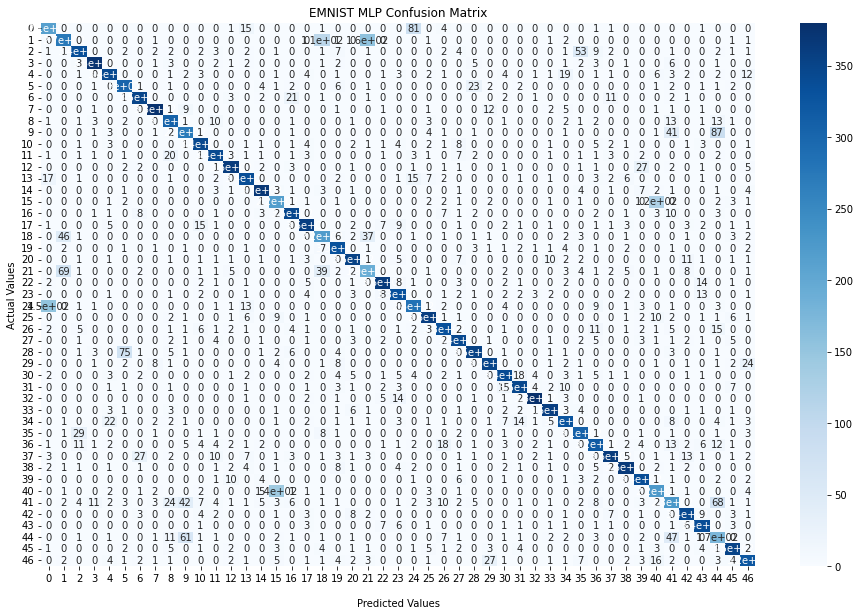

In [8]:
showConfusionMatrix(mlp1, X_test, y_test, 'EMNIST MLP Confusion Matrix')

Evaluation of MNIST + EMNIST MLP:

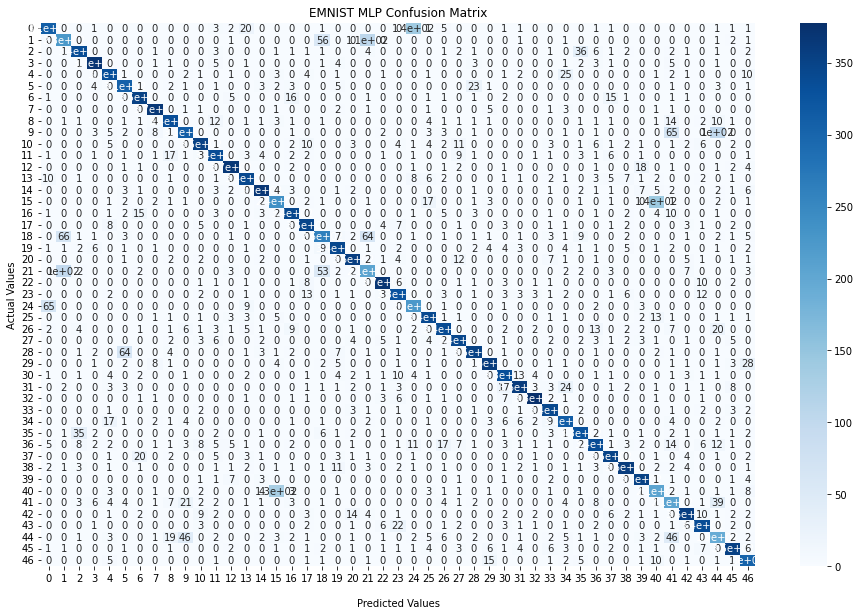

In [9]:
showConfusionMatrix(mlp2, X_test, y_test, 'EMNIST MLP Confusion Matrix')

In [17]:
print(classification_report(y_test, mlp1.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.67      0.53      0.59       400
         1.0       0.50      0.69      0.58       400
         2.0       0.77      0.84      0.80       400
         3.0       0.92      0.94      0.93       400
         4.0       0.83      0.86      0.84       400
         5.0       0.86      0.76      0.80       400
         6.0       0.88      0.88      0.88       400
         7.0       0.91      0.94      0.93       400
         8.0       0.84      0.77      0.80       400
         9.0       0.65      0.68      0.67       400
        10.0       0.88      0.86      0.87       400
        11.0       0.86      0.86      0.86       400
        12.0       0.87      0.90      0.89       400
        13.0       0.84      0.84      0.84       400
        14.0       0.92      0.92      0.92       400
        15.0       0.60      0.54      0.57       400
        16.0       0.88      0.86      0.87       400
        17.0       0.86    

In [14]:
print(classification_report(y_test, mlp2.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.63      0.78      0.70       400
         1.0       0.57      0.56      0.57       400
         2.0       0.83      0.84      0.83       400
         3.0       0.93      0.93      0.93       400
         4.0       0.85      0.83      0.84       400
         5.0       0.86      0.77      0.81       400
         6.0       0.88      0.88      0.88       400
         7.0       0.95      0.92      0.93       400
         8.0       0.84      0.84      0.84       400
         9.0       0.61      0.78      0.69       400
        10.0       0.84      0.88      0.86       400
        11.0       0.84      0.84      0.84       400
        12.0       0.91      0.92      0.91       400
        13.0       0.86      0.86      0.86       400
        14.0       0.88      0.92      0.90       400
        15.0       0.57      0.59      0.58       400
        16.0       0.86      0.86      0.86       400
        17.0       0.90    